# Nb to explore visual HB activity estimation

In [ ]:
import os, sys, cv2
import pandas as pd
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', 1000)  # Set a wide width for display
pd.set_option('display.colheader_justify', 'center')  # Align column headers
sys.path.append('..') # Add parent folder to path
sys.path.append('../RHCVisualisation')
sys.path.append('../RHCVisualisation/RHCThermalPlots')
sys.path.append('../RHCVisualisation/RHCImaging')
from RHCVisualisation.RHCImaging.libimage import fetchImagesPaths
from RHCVisualisation.libvisu import Hive, thermal_shifts
from RHCVisualisation.RHCImaging.VideoManagment.videolib import initVideoWriter
import matplotlib.pyplot as plt
from libActivity import computeHtrsActivity
from libaSensing import getExpDTs
from tqdm import tqdm

## Congfiguration

In [2]:
hive_nb = 1
exp_based = True
if exp_based:
    exp = 'aSensing1'  # 'aSensing1', 'aSensing2' or 'aSensing3'
#     start_ts, stop_ts = getExpDTs(exp, hive_nb)
# else:
#     start_ts=pd.Timestamp("2024-10-28 10:50:00").tz_localize('UTC')
#     stop_ts=pd.Timestamp("2024-10-28 13:00:00").tz_localize('UTC')

rootpath_imgs = '/Users/cyrilmonette/Library/CloudStorage/SynologyDrive-data/24.11_aSensing_OH/Images/'
img_freq = "1min" # Sampling frequency of images
start_ts = pd.Timestamp("2024-11-07 02:00:00").tz_localize('UTC')
time_window = pd.Timedelta("45 minutes")

verbose = False

## Main code

In [3]:
print(f"Will gather images between {start_ts} and {start_ts + time_window} every {img_freq}.")
all_ts = pd.date_range(start=start_ts, end=start_ts + time_window, freq=img_freq)
imgs_paths = fetchImagesPaths(rootpath_imgs, all_ts, hive_nb, images_fill_limit=0, verbose=verbose)
print(imgs_paths.head())

Will gather images between 2024-11-07 02:00:00+00:00 and 2024-11-07 02:45:00+00:00 every 1min.
                                                 h1r1                                               h1r2                                               h1r3                                               h1r4                       
2024-11-07 02:00:00+00:00  /Users/cyrilmonette/Library/CloudStorage/Synol...  /Users/cyrilmonette/Library/CloudStorage/Synol...  /Users/cyrilmonette/Library/CloudStorage/Synol...  /Users/cyrilmonette/Library/CloudStorage/Synol...
2024-11-07 02:01:00+00:00  /Users/cyrilmonette/Library/CloudStorage/Synol...  /Users/cyrilmonette/Library/CloudStorage/Synol...  /Users/cyrilmonette/Library/CloudStorage/Synol...  /Users/cyrilmonette/Library/CloudStorage/Synol...
2024-11-07 02:02:00+00:00  /Users/cyrilmonette/Library/CloudStorage/Synol...  /Users/cyrilmonette/Library/CloudStorage/Synol...  /Users/cyrilmonette/Library/CloudStorage/Synol...  /Users/cyrilmonette/Library/CloudSt

In [4]:
# Load images to hive objects
hives = []
for dt in tqdm(all_ts):
    ts_images = []
    ts_names = []
    img_path = imgs_paths.loc[dt].copy()
    for col in img_path.index:
        img = cv2.imread(img_path[col], cv2.IMREAD_GRAYSCALE)
        img_name = img_path[col].split(os.sep)[-1][:-4]
        ts_images.append(img)
        ts_names.append(img_name)

    _hive = Hive(dt, ts_images, False, ts_names, hive_nb=hive_nb)
    _hive.setThermalShifts(thermal_shifts[exp][hive_nb])
    hives.append(_hive)

100%|██████████| 46/46 [00:06<00:00,  7.61it/s]


In [5]:
images_diffs = []
for i in range(1, len(hives)):
    diffs = []
    names = []
    for j in range(len(hives[i].imgs)):
        diff = cv2.absdiff(hives[i].imgs[j], hives[i-1].imgs[j])
        _, activity_mask = cv2.threshold(diff, 25, 255, cv2.THRESH_BINARY)
        diffs.append(activity_mask)
        names.append(f"diff_{hives[i].imgs_names[j]}")

    diff_hive = Hive(hives[i].ts, diffs, True, names, hive_nb=hive_nb)
    images_diffs.append(diff_hive)

In [6]:
print(hives[0].htr_pos[0]['h00'])

((3585, 560), (4385, 1360))


(2592, 4608)


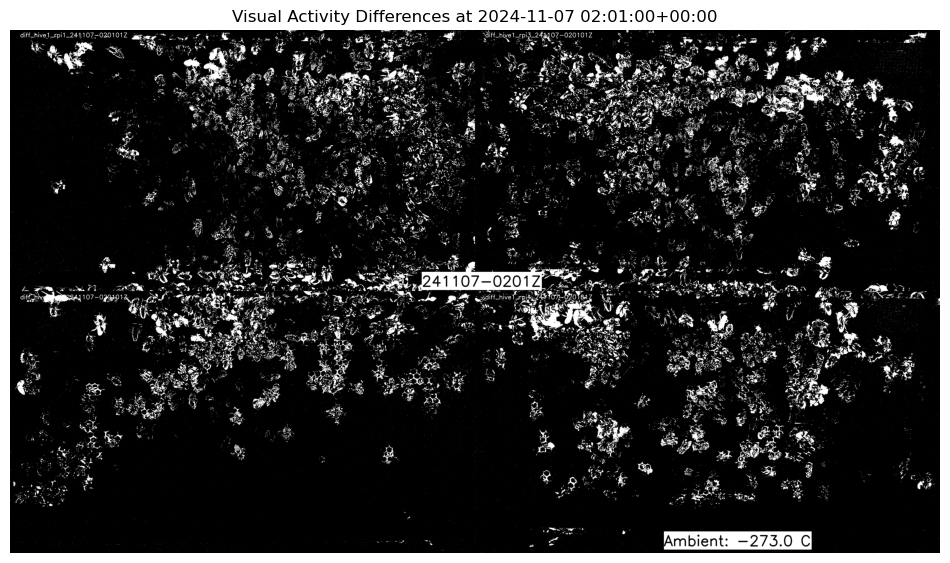

In [7]:
index = 0  # Change index to visualize different time points
snapshot = images_diffs[index].snapshot()
print(images_diffs[index].imgs[0].shape)
plt.figure(figsize=(12, 8))
plt.imshow(snapshot)
plt.axis('off')
plt.title(f"Visual Activity Differences at {images_diffs[index].ts}")
plt.show()

### Compute activity metric

Computed activity metrics for 45 time intervals.


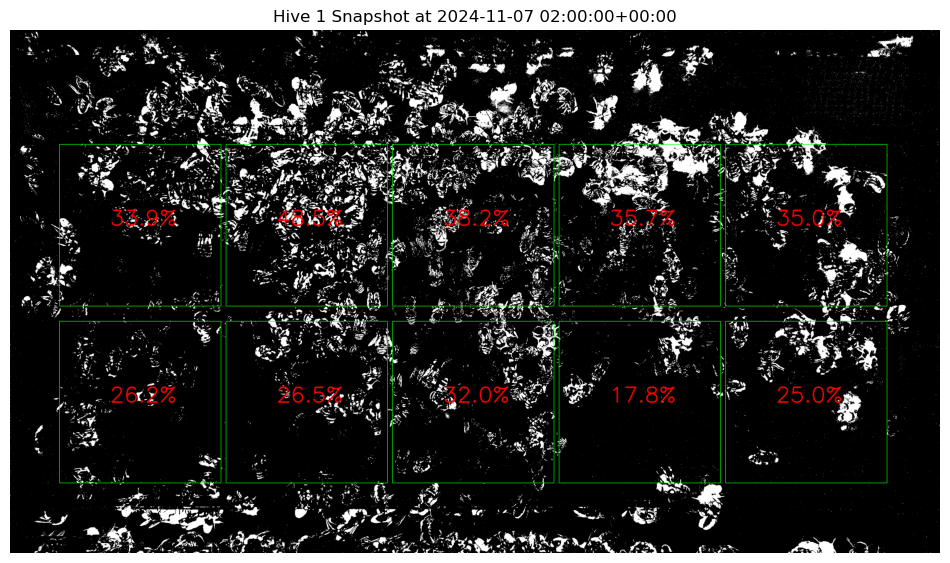

In [ ]:
activities = []
for i in range(1, len(hives)):
    hive1 = hives[i-1]
    hive2 = hives[i]
    activity_metrics = computeHtrsActivity(hive1, hive2, threshold=25, verbose=False)
    activities.append(activity_metrics)

print(f"Computed activity metrics for {len(activities)} time intervals.")

rpi_focus = 2
ts_focus = 0
diff_image = images_diffs[ts_focus].imgs[rpi_focus]
diff_image_rgb = cv2.cvtColor(diff_image, cv2.COLOR_GRAY2BGR)
htr_pos = images_diffs[ts_focus].htr_pos[rpi_focus]
_activities = activities[ts_focus]
# Anotate activiy_values on diff_image
for htr_id, pos in htr_pos.items():
    x, y = pos[0]
    y += 400  # Offset text position
    x += 250
    activity_value = _activities.activity_values[rpi_focus][htr_id]
    activity_value = str(round(100 * activity_value, 1)) + '%'
    # Put a rectangle around the heaters using pos ((top-left),(bottom-right))
    cv2.rectangle(diff_image_rgb, pos[0], pos[1], (0, 255, 0), 2)
    cv2.putText(diff_image_rgb, activity_value, (x, y), cv2.FONT_HERSHEY_SIMPLEX, 3.5, (255, 0, 0), 5, cv2.LINE_AA)

plt.figure(figsize=(12, 8))
plt.imshow(diff_image_rgb)
plt.axis('off')
plt.title(f"Hive {hive_nb} Snapshot at {hives[0].ts}")
plt.show()

### Save video

In [9]:
dest = 'outputVideos'
filename = f'hive{hive_nb}_A_{start_ts.strftime("%Y%m%d_%H%M")}_{(start_ts + time_window).strftime("%Y%m%d_%H%M")}'
video = initVideoWriter(dest, shape=images_diffs[0].snapshot().shape, name=filename, fps=10) # RGB video
for diff_hive in images_diffs:
    frame = diff_hive.snapshot()
    video.write(frame)

video.release()